In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("predictive_maintenance_v3.csv")

In [3]:
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(24042, 15)

In [6]:
df.columns

Index(['timestamp', 'machine_id', 'machine_type', 'vibration_rms',
       'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm',
       'operating_mode', 'hours_since_maintenance', 'ambient_temp',
       'rul_hours', 'failure_within_24h', 'failure_type',
       'estimated_repair_cost'],
      dtype='object')

In [ ]:
df.columns=df.columns.str.strip()

In [8]:
df.drop(columns=['failure_within_24h','failure_type','estimated_repair_cost','timestamp'],inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   machine_id               24042 non-null  int64  
 1   machine_type             24042 non-null  object 
 2   vibration_rms            23042 non-null  float64
 3   temperature_motor        23208 non-null  float64
 4   current_phase_avg        23311 non-null  float64
 5   pressure_level           23118 non-null  float64
 6   rpm                      23509 non-null  float64
 7   operating_mode           24042 non-null  object 
 8   hours_since_maintenance  24042 non-null  float64
 9   ambient_temp             24042 non-null  float64
 10  rul_hours                24042 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 2.0+ MB


In [10]:
df.isnull().sum().sort_values(ascending=False)

vibration_rms              1000
pressure_level              924
temperature_motor           834
current_phase_avg           731
rpm                         533
machine_type                  0
machine_id                    0
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
dtype: int64

In [11]:
df.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000


In [12]:
X=df.drop('rul_hours',axis=1)
Y=df['rul_hours']

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
numeric_features = [
    'machine_id',
    'vibration_rms',
    'temperature_motor',
    'current_phase_avg',
    'pressure_level',
    'rpm',
    'hours_since_maintenance',
    'ambient_temp'
]

categorical_features = [
    'machine_type',
    'operating_mode'
]

numeric_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first'
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [15]:
from sklearn.linear_model import LinearRegression

model_l = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

model_l.fit(X_train, Y_train)

y_pred_l = model_l.predict(X_test)

print('Linear Regression')
print('MSE:', mean_squared_error(Y_test, y_pred_l))
print('MAE:', mean_absolute_error(Y_test, y_pred_l))
print('R2 :', r2_score(Y_test, y_pred_l))

Linear Regression
MSE: 591.4001836563716
MAE: 20.406231577921883
R2 : 0.14467011147445885


In [16]:
from sklearn.svm import SVR

model_s = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])

model_s.fit(X_train, Y_train)

y_pred_s = model_s.predict(X_test)

print('SVR')
print('MSE:', mean_squared_error(Y_test, y_pred_s))
print('MAE:', mean_absolute_error(Y_test, y_pred_s))
print('R2 :', r2_score(Y_test, y_pred_s))

SVR
MSE: 557.0937533187263
MAE: 17.85958781757207
R2 : 0.19428679413253724


In [17]:
from sklearn.tree import DecisionTreeRegressor

model_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

model_dt.fit(X_train, Y_train)

y_pred_dt = model_dt.predict(X_test)

print('Decision Tree')
print('MSE:', mean_squared_error(Y_test, y_pred_dt))
print('MAE:', mean_absolute_error(Y_test, y_pred_dt))
print('R2 :', r2_score(Y_test, y_pred_dt))

Decision Tree
MSE: 92.30181147847784
MAE: 3.2130006238303186
R2 : 0.8665057937004896


In [18]:
from sklearn.ensemble import RandomForestRegressor

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, Y_train)

y_pred_rf = model_rf.predict(X_test)

print('Random Forest')
print('MSE:', mean_squared_error(Y_test, y_pred_rf))
print('MAE:', mean_absolute_error(Y_test, y_pred_rf))
print('R2 :', r2_score(Y_test, y_pred_rf))

Random Forest
MSE: 52.50434857952381
MAE: 3.1114253483052607
R2 : 0.9240640435043828


In [19]:
X_train.head()

,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp
10484,9,Pump,2.28,68.13,12.20,116.5,1196.0,normal,438.13,14.7
18424,16,Robotic Arm,1.25,40.14,5.74,46.9,353.7,normal,464.85,14.5
10397,9,Pump,0.67,41.94,3.62,17.6,530.0,idle,413.70,10.7
15647,14,Compressor,1.09,49.30,5.97,45.5,731.7,idle,261.99,15.5
6730,6,Pump,1.91,48.49,11.86,114.5,1303.7,normal,126.33,13.3


In [20]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

model_gb.fit(X_train, Y_train)

y_pred_gb = model_gb.predict(X_test)

print('Gradient Boosting')
print('MSE:', mean_squared_error(Y_test, y_pred_gb))
print('MAE:', mean_absolute_error(Y_test, y_pred_gb))
print('R2 :', r2_score(Y_test, y_pred_gb))

Gradient Boosting
MSE: 256.48946806443655
MAE: 12.199119400115977
R2 : 0.629044572202905


In [21]:
from xgboost import XGBRegressor

model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ))
])

model_xgb.fit(X_train, Y_train)

y_pred_xgb = model_xgb.predict(X_test)

print('XGBoost')
print('MSE:', mean_squared_error(Y_test, y_pred_xgb))
print('MAE:', mean_absolute_error(Y_test, y_pred_xgb))
print('R2 :', r2_score(Y_test, y_pred_xgb))

XGBoost
MSE: 100.76496701986893
MAE: 6.783816362296426
R2 : 0.854265706385944


In [22]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid={
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': ['sqrt', 1.0]
    },
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

In [23]:
grid_search.fit(X_train, Y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 1.0], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multipl

In [24]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV MAE:
3.773946435813445


In [26]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 3.1076774069453097
RMSE: 7.219037680935771
R2  : 0.924627866177202


In [27]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.named_steps['model'].feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
6,num__hours_since_maintenance,0.607336
0,num__machine_id,0.166971
5,num__rpm,0.062179
2,num__temperature_motor,0.040077
1,num__vibration_rms,0.027410
3,num__current_phase_avg,0.025183
8,cat__machine_type_Compressor,0.022331
9,cat__machine_type_Pump,0.017807
4,num__pressure_level,0.014960
7,num__ambient_temp,0.009143


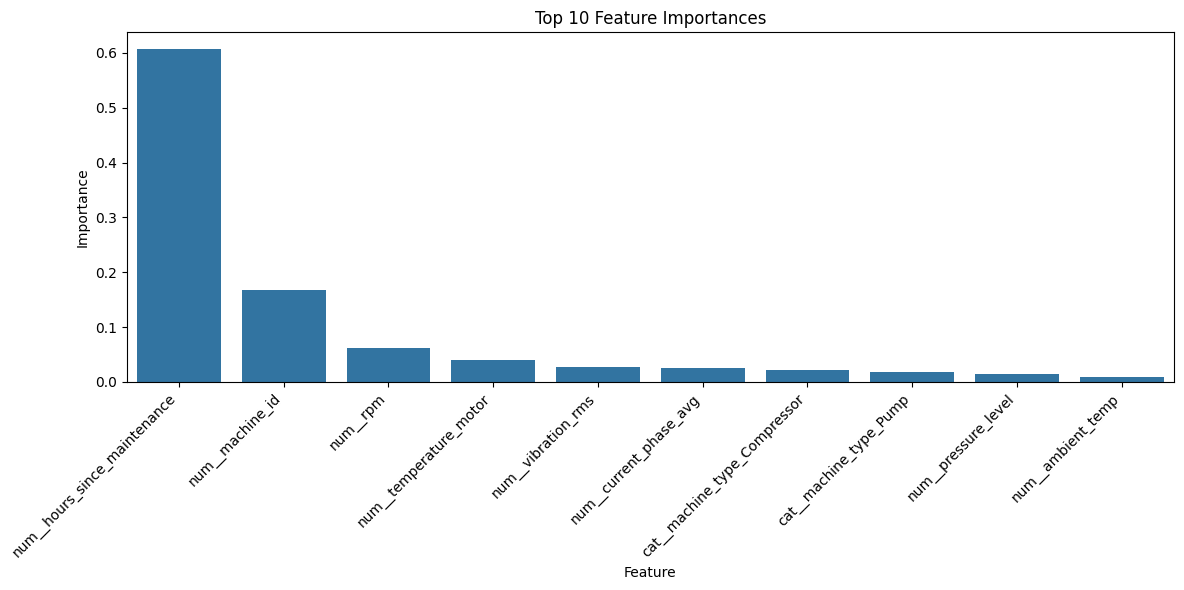

In [29]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Feature',
    y='Importance'
)

plt.title('Top 10 Feature Importances')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.tight_layout()
plt.show()

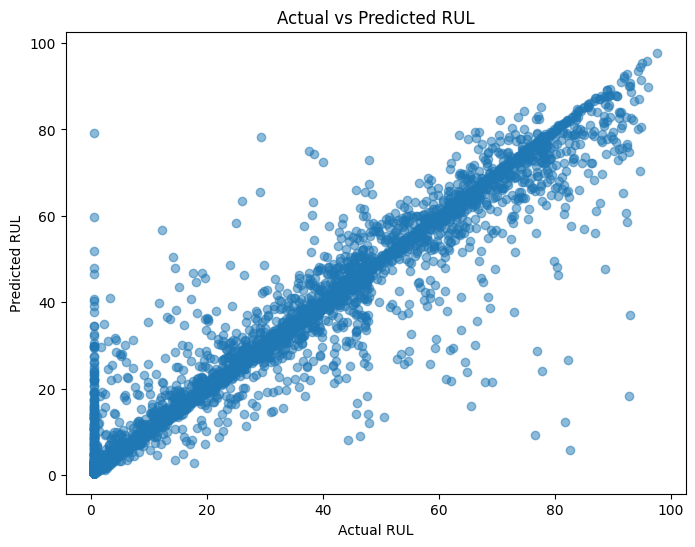

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(Y_test, y_pred, alpha=0.5)

plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Actual vs Predicted RUL')

plt.show()

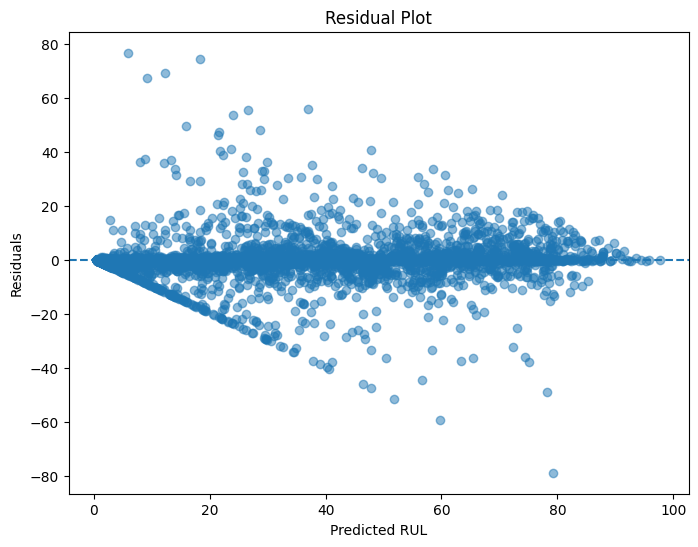

In [31]:
residuals = Y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted RUL')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [32]:
import joblib

# Save the complete pipeline
joblib.dump(best_rf, "rul_pipeline.pkl")

print("RUL Pipeline saved successfully!")

RUL Pipeline saved successfully!
